In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

from dotenv import load_dotenv
from pydantic import BaseModel
from langchain.chat_models import init_chat_model

df = pd.read_csv(
    "../data/Superstore.csv",
    encoding="windows-1252"
)

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South

In [67]:
class ChartType(BaseModel):
    chart_type: str


In [68]:
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv(
    "GROQ_API_KEY"
)

llm = init_chat_model(
    model="llama-3.3-70b-versatile",
    model_provider="groq"
)

In [69]:
chart_llm = llm.with_structured_output(
    ChartType
)

In [70]:
def extract_code(response):

    match = re.search(
        r"```(?:python)?\n(.*?)```",
        response,
        re.DOTALL
    )

    if match:
        return match.group(1).strip()

    return response.strip()

In [71]:
def generate_query(question):

    columns = df.columns.tolist()

    prompt = f"""
You are a senior pandas expert.

The dataframe name is df.

Available columns:
{columns}

Order Date and Ship Date are datetime columns.

Rules:

1. Understand the business question.

2. Aggregate before ranking.

3. Use groupby when needed.

4. For trends over time use:
pd.Grouper(key='Order Date', freq='ME')

5. If the output will likely be visualized,
prefer using reset_index().

IMPORTANT:
Return ONLY a pandas expression.
No explanation.
No markdown.
No code fences.

Question:
{question}
"""

    response = llm.invoke(prompt)

    return extract_code(
        response.content
    )

In [72]:
def execute_query(query):

    try:

        return eval(
            query,
            {
                "df": df,
                "pd": pd
            }
        )

    except Exception as e:

        return str(e)

In [73]:
def fix_query(
    question,
    query,
    error
):

    prompt = f"""
You are a senior pandas expert.

Question:
{question}

Failed Query:
{query}

Error:
{error}

Fix the query.

Return ONLY the corrected pandas expression.
No explanation.
No markdown.
"""

    response = llm.invoke(prompt)

    return extract_code(
        response.content
    )

In [74]:
def execute_with_retry(
    question,
    query
):

    result = execute_query(query)

    if not isinstance(result, str):
        return query, result

    print("Error:")
    print(result)

    fixed_query = fix_query(
        question,
        query,
        result
    )

    print("\nFixed Query:")
    print(fixed_query)

    result = execute_query(
        fixed_query
    )

    return fixed_query, result

In [75]:
def needs_visualization(question):

    keywords = [
        "chart",
        "graph",
        "plot",
        "trend",
        "visualize",
        "distribution",
        "share",
        "compare",
        "show"
    ]

    question = question.lower()

    return any(
        keyword in question
        for keyword in keywords
    )

In [76]:
def detect_chart_type(question):

    prompt = f"""
You are a data visualization expert.

Choose one:

- bar
- line
- pie
- histogram

Rules:

Trend over time -> line

Distribution -> histogram

Share -> pie

Category comparison -> bar

Question:
{question}
"""

    response = chart_llm.invoke(
        prompt
    )

    return response.chart_type.lower()

In [77]:
def create_chart(
    result,
    chart_type
):

    plt.figure(figsize=(10,5))

    if chart_type == "line":

        if isinstance(result, pd.Series):

            plt.plot(
                result.index,
                result.values
            )

        elif isinstance(result, pd.DataFrame):

            plt.plot(
                result.iloc[:,0],
                result.iloc[:,1]
            )

    elif chart_type == "bar":

        if isinstance(result, pd.Series):

            plt.bar(
                result.index.astype(str),
                result.values
            )

        elif isinstance(result, pd.DataFrame):

            plt.bar(
                result.iloc[:,0],
                result.iloc[:,1]
            )

    elif chart_type == "histogram":

        if isinstance(result, pd.Series):

            plt.hist(result.values)

        elif isinstance(result, pd.DataFrame):

            plt.hist(
                result.iloc[:,0]
            )

    elif chart_type == "pie":

        if isinstance(result, pd.Series):

            plt.pie(
                result.values,
                labels=result.index.astype(str),
                autopct="%1.1f%%"
            )

        elif isinstance(result, pd.DataFrame):

            plt.pie(
                result.iloc[:,1],
                labels=result.iloc[:,0],
                autopct="%1.1f%%"
            )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [78]:
def explain_result(
    question,
    result
):

    prompt = f"""
You are a business analyst.

Question:
{question}

Result:
{result}

Explain the result.

Do not make assumptions.
Keep it concise.
"""

    return llm.invoke(
        prompt
    ).content

In [79]:
def data_agent(question):

    query = generate_query(
        question
    )

    print(
        f"\nGenerated Query:\n{query}\n"
    )

    query, result = execute_with_retry(
        question,
        query
    )

    print(
        f"\nResult:\n{result}\n"
    )

    visualize = needs_visualization(
        question
    )

    print(
        "Visualization:",
        visualize
    )

    if visualize:

        chart_type = detect_chart_type(
            question
        )

        print(
            "Chart Type:",
            chart_type
        )

        create_chart(
            result,
            chart_type
        )

    explanation = explain_result(
        question,
        result
    )

    return {
        "query": query,
        "result": result,
        "explanation": explanation
    }


Generated Query:
df.groupby('Category')['Sales'].sum().reset_index()


Result:
          Category        Sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330

Visualization: True
Chart Type: bar


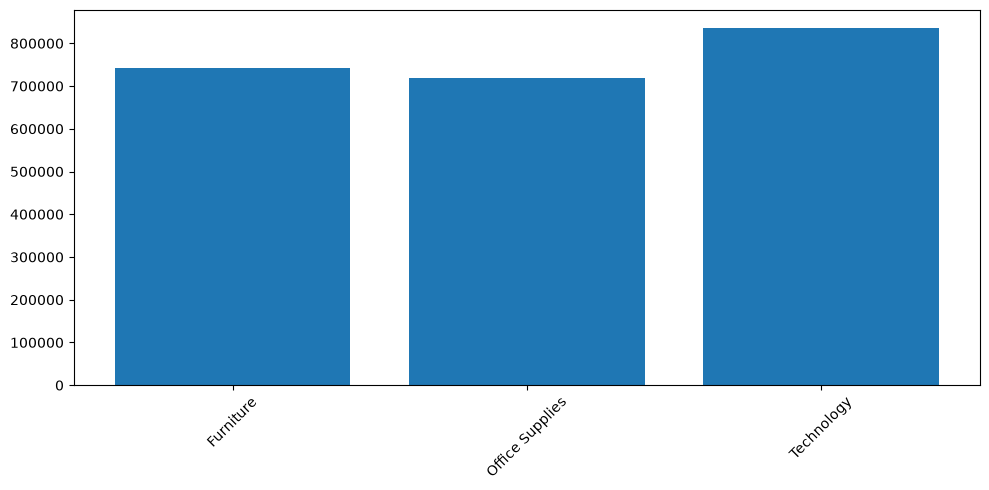

{'query': "df.groupby('Category')['Sales'].sum().reset_index()",
 'result':           Category        Sales
 0        Furniture  741999.7953
 1  Office Supplies  719047.0320
 2       Technology  836154.0330,
 'explanation': 'The result shows sales figures for three categories: \n\n- Furniture: $741,999.79\n- Office Supplies: $719,047.03\n- Technology: $836,154.03\n\nTechnology has the highest sales, followed by Furniture, and then Office Supplies.'}

In [80]:
data_agent(
    "Show sales by category"
)


Generated Query:
df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()


Result:
   Order Date        Sales
0  2014-01-31   14236.8950
1  2014-02-28    4519.8920
2  2014-03-31   55691.0090
3  2014-04-30   28295.3450
4  2014-05-31   23648.2870
5  2014-06-30   34595.1276
6  2014-07-31   33946.3930
7  2014-08-31   27909.4685
8  2014-09-30   81777.3508
9  2014-10-31   31453.3930
10 2014-11-30   78628.7167
11 2014-12-31   69545.6205
12 2015-01-31   18174.0756
13 2015-02-28   11951.4110
14 2015-03-31   38726.2520
15 2015-04-30   34195.2085
16 2015-05-31   30131.6865
17 2015-06-30   24797.2920
18 2015-07-31   28765.3250
19 2015-08-31   36898.3322
20 2015-09-30   64595.9180
21 2015-10-31   31404.9235
22 2015-11-30   75972.5635
23 2015-12-31   74919.5212
24 2016-01-31   18542.4910
25 2016-02-29   22978.8150
26 2016-03-31   51715.8750
27 2016-04-30   38750.0390
28 2016-05-31   56987.7280
29 2016-06-30   40344.5340
30 2016-07-31   39261.9630
31 2016-08-31   31115.3743


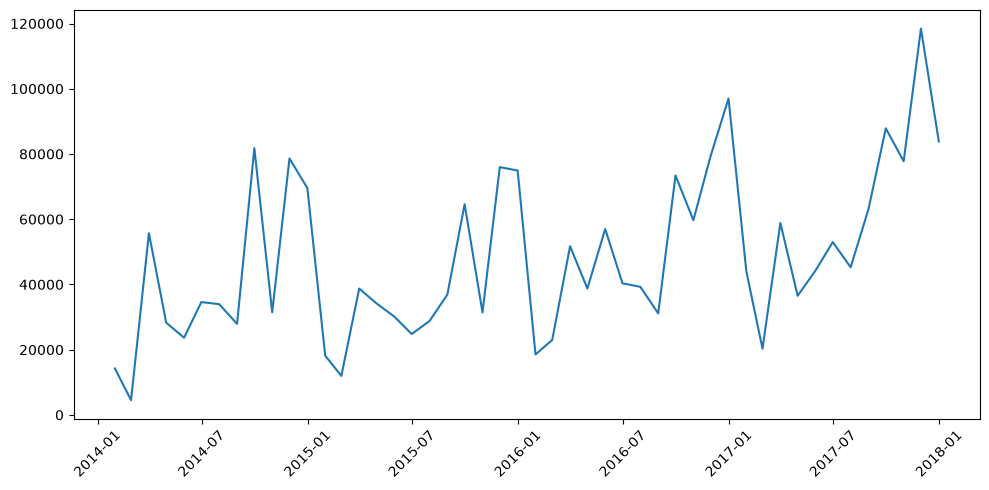

{'query': "df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()",
 'result':    Order Date        Sales
 0  2014-01-31   14236.8950
 1  2014-02-28    4519.8920
 2  2014-03-31   55691.0090
 3  2014-04-30   28295.3450
 4  2014-05-31   23648.2870
 5  2014-06-30   34595.1276
 6  2014-07-31   33946.3930
 7  2014-08-31   27909.4685
 8  2014-09-30   81777.3508
 9  2014-10-31   31453.3930
 10 2014-11-30   78628.7167
 11 2014-12-31   69545.6205
 12 2015-01-31   18174.0756
 13 2015-02-28   11951.4110
 14 2015-03-31   38726.2520
 15 2015-04-30   34195.2085
 16 2015-05-31   30131.6865
 17 2015-06-30   24797.2920
 18 2015-07-31   28765.3250
 19 2015-08-31   36898.3322
 20 2015-09-30   64595.9180
 21 2015-10-31   31404.9235
 22 2015-11-30   75972.5635
 23 2015-12-31   74919.5212
 24 2016-01-31   18542.4910
 25 2016-02-29   22978.8150
 26 2016-03-31   51715.8750
 27 2016-04-30   38750.0390
 28 2016-05-31   56987.7280
 29 2016-06-30   40344.5340
 30 2016-07-31   39261.9630


In [81]:
data_agent(
    "Show monthly sales trend"
)


Generated Query:
df['Sales'].value_counts().reset_index()


Result:
        Sales  count
0      12.960     56
1      15.552     39
2      19.440     39
3      25.920     36
4      10.368     36
...       ...    ...
5820   13.860      1
5821   13.376      1
5822  437.472      1
5823   97.980      1
5824  243.160      1

[5825 rows x 2 columns]

Visualization: True
Chart Type: histogram


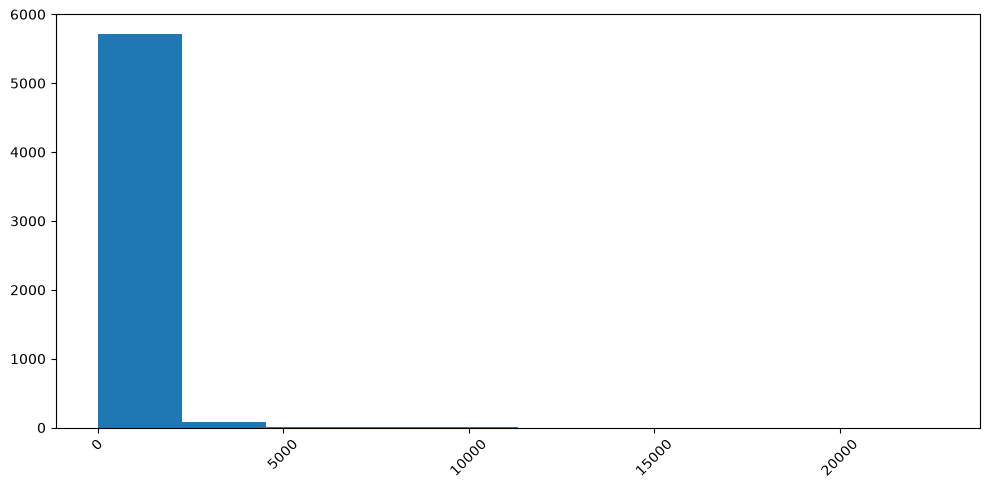

{'query': "df['Sales'].value_counts().reset_index()",
 'result':         Sales  count
 0      12.960     56
 1      15.552     39
 2      19.440     39
 3      25.920     36
 4      10.368     36
 ...       ...    ...
 5820   13.860      1
 5821   13.376      1
 5822  437.472      1
 5823   97.980      1
 5824  243.160      1
 
 [5825 rows x 2 columns],
 'explanation': 'The result shows a distribution of sales amounts with their corresponding frequencies. There are 5825 unique sales amounts, each with a count of how many times it occurs. The sales amounts range from approximately 10 to 437, with most having a low frequency (1) and a few having higher frequencies (up to 56).'}

In [82]:
data_agent(
    "Show sales distribution"
)

In [84]:
response = data_agent(
    "Top 5 products by profit"
)


Generated Query:
df.groupby('Product Name')['Profit'].sum().reset_index().sort_values('Profit', ascending=False).head(5)


Result:
                                          Product Name      Profit
404              Canon imageCLASS 2200 Advanced Copier  25199.9280
650  Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
805               Hewlett Packard LaserJet 3310 Copier   6983.8836
400                 Canon PC1060 Personal Laser Copier   4570.9347
787  HP Designjet T520 Inkjet Large Format Printer ...   4094.9766

Visualization: False
